# Amazon ML Challenge 2026: Business Entity Resolution
## Complete Preprocessing & Blocking Pipeline for Transformer Training

In [1]:
import os
import re
import random
import time
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Styling for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Environment initialized successfully.")


Environment initialized successfully.


## 1. Inspecting the Raw Source Datasets

In [2]:
# Inspect sample rows from each dataset
s1_sample = pd.read_csv('dataset/train/train_source1.tsv', sep='\t', nrows=3)
s2_sample = pd.read_csv('dataset/train/train_source2.tsv', sep='\t', nrows=3)
s3_sample = pd.read_csv('dataset/train/train_source3.tsv', sep='\t', nrows=3)
gt_sample = pd.read_csv('dataset/train/train_ground_truth.tsv', sep='\t', nrows=3)

print("Source 1 Sample Three Rows")
display(s1_sample)

print("\n Source 2 Sample Three Rows")
display(s2_sample)

print("\n Source 3 Sample Three Rows")
display(s3_sample)

print("\n Ground Truth Sample Three Rows")
display(gt_sample)


Source 1 Sample Three Rows


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US



 Source 2 Sample Three Rows


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India



 Source 3 Sample Three Rows


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,NaN,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US



 Ground Truth Sample Three Rows


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"


## 2. Ground Truth Analysis & Singleton Detection

Total S1 entities in Ground Truth: 2,206,821
Total True Positive Pairs:       7,638,365
Singletons (0 matches):          123,247 (5.58%)
Average matches per S1:          3.46
Max matches for a single S1:     11


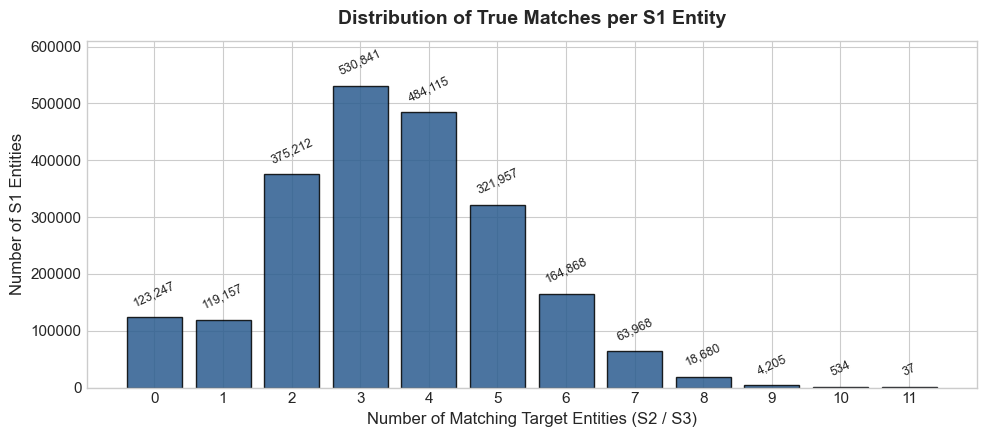

In [3]:
gt = pd.read_csv('dataset/train/train_ground_truth.tsv', sep='\t')
match_counts = gt['matched_entity_ids'].fillna('').apply(lambda x: len(x.split(',')) if x.strip() else 0)

print(f"Total S1 entities in Ground Truth: {len(gt):,}")
print(f"Total True Positive Pairs:       {match_counts.sum():,}")
print(f"Singletons (0 matches):          {(match_counts == 0).sum():,} ({(match_counts == 0).mean()*100:.2f}%)")
print(f"Average matches per S1:          {match_counts.mean():.2f}")
print(f"Max matches for a single S1:     {match_counts.max()}")

fig, ax = plt.subplots(figsize=(10, 4.5))
counts_dist = match_counts.value_counts().sort_index()
bars = ax.bar(counts_dist.index, counts_dist.values, color='#2b5c8f', edgecolor='black', alpha=0.85)
ax.set_title('Distribution of True Matches per S1 Entity', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Matching Target Entities (S2 / S3)', fontsize=12)
ax.set_ylabel('Number of S1 Entities', fontsize=12)
ax.set_xticks(counts_dist.index)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 15000, f'{yval:,}', ha='center', va='bottom', fontsize=9, rotation=25)
ax.set_ylim(0, max(counts_dist.values) * 1.15)
plt.tight_layout()
plt.show()


## 3. Name & Address Blocking / Binning Strategy

In [4]:
# Implementation of blocking key extractors
LEGAL_STOP_WORDS = {
    'inc', 'incorporated', 'llc', 'ltd', 'limited', 'pvt', 'private', 'corp', 'corporation',
    'co', 'company', 'enterprises', 'enterprise', 'services', 'service', 'solutions',
    'the', 'and', 'of', '&', 'group', 'industries', 'industry', 'holdings', 'holding'
}

def extract_name_key(name):
    """Extract primary significant semantic token from business name."""
    if not name or pd.isna(name):
        return ''
    tokens = re.findall(r'[a-zA-Z0-9]+', str(name).lower())
    sig_tokens = [t for t in tokens if t not in LEGAL_STOP_WORDS and len(t) >= 3]
    return sig_tokens[0] if sig_tokens else (tokens[0] if tokens else '')

def extract_addr_key(addr, country):
    """Extract postal code or primary location token from address."""
    if not addr or pd.isna(addr):
        return ''
    addr_str = str(addr)
    if country == 'India':
        pins = re.findall(r'\b[1-9]\d{5}\b', addr_str)
        if pins:
            return 'pin_' + pins[0]
    elif country == 'US':
        zips = re.findall(r'\b\d{5}\b', addr_str)
        if zips:
            return 'zip_' + zips[0]
    tokens = re.findall(r'[a-zA-Z0-9]+', addr_str.lower())
    if tokens and len(tokens[0]) >= 3:
        return 'addr_' + tokens[0]
    return ''

# Demonstration on realistic noisy examples
demo_records = [
    ("Maure Williams Colombier Inc", "85 Wayne Avenue, Ticonderoga, NY", "US"),
    ("Maure Wilblims Colombier", "Wayne Ave, Ticonderoga, 12883, NY", "US"),
    ("Raj Investments LLP", "6(29), C.I.T. Colony, Mylapore, Chennai, 600004", "India"),
    ("ராಜ್ இன்வெஸ்ட்மெண்ட்ஸ்", "6(29), C.I.T. COLONY, CHENNAI, 600004", "India"),
    ("Payne Enterprises", "3315 Fremont Street, Peoria, IL", "US"),
]

print("=== Demonstration of Blocking Key Extraction ===")
for name, addr, ctry in demo_records:
    nk = extract_name_key(name)
    ak = extract_addr_key(addr, ctry)
    print(f"Name: {name:<32} | Name Key: {nk:<12} | Addr Key: {ak}")


=== Demonstration of Blocking Key Extraction ===
Name: Maure Williams Colombier Inc     | Name Key: maure        | Addr Key: 
Name: Maure Wilblims Colombier         | Name Key: maure        | Addr Key: zip_12883
Name: Raj Investments LLP              | Name Key: raj          | Addr Key: pin_600004
Name: ராಜ್ இன்வெஸ்ட்மெண்ட்ஸ்           | Name Key:              | Addr Key: pin_600004
Name: Payne Enterprises                | Name Key: payne        | Addr Key: addr_3315


## 4. Hard Negative Mining vs Random Negatives

In [5]:
# Inspect preprocessed dataset to show True Match vs Hard Negative contrast
df_sample = pd.read_csv('output/transformer_training_pairs.tsv', sep='\t', nrows=6)

print("=== True Matches (label = 1) ===")
pos_rows = df_sample[df_sample['label'] == 1].head(2)
for _, r in pos_rows.iterrows():
    print(f"S1_ID: {r['S1_ID']} -> Target: {r['Target_ID']} ({r['Target_Source']})")
    print(f"  text_a: {r['text_a']}")
    print(f"  text_b: {r['text_b']}\n")

print("=== Hard Negative Candidate (label = 0) ===")
neg_rows = df_sample[df_sample['label'] == 0].head(1)
for _, r in neg_rows.iterrows():
    print(f"S1_ID: {r['S1_ID']} -> Target: {r['Target_ID']} ({r['Target_Source']})")
    print(f"  text_a: {r['text_a']}")
    print(f"  text_b: {r['text_b']}\n")


=== True Matches (label = 1) ===
S1_ID: S1-925783039 -> Target: S2-157377754 (Source 2)
  text_a: Business Name: Orelee's Barbershop Address: 1795 Westchester Drive, High Point, NC Country: US
  text_b: Business Name: Orelee's Barbershop Address: 1795 WESTCHESTER DRIVE, NC, HIGH POINT Country: US

S1_ID: S1-925783039 -> Target: S2-517291332 (Source 2)
  text_a: Business Name: Orelee's Barbershop Address: 1795 Westchester Drive, High Point, NC Country: US
  text_b: Business Name: Orelee's Bárbershop Address: 1795 Westchester Drive, HIGH POINT, NC Country: US

=== Hard Negative Candidate (label = 0) ===
S1_ID: S1-925783039 -> Target: S2-470914905 (Source 2)
  text_a: Business Name: Orelee's Barbershop Address: 1795 Westchester Drive, High Point, NC Country: US
  text_b: Business Name: Orelee Joven  First Biotech Center Co Address: 405 CHESTNUT AVE, LAKE CITY, TN Country: US



## 5. Transformer Text Formatting

=== Final Preprocessed Dataset Summary ===
File Path:         output/transformer_training_pairs.tsv
File Size on Disk: 3.82 GB
Total Candidate Pairs: 15,399,977
Positive Matches (1):  7,638,365 (49.60%)
Negative Matches (0):  7,761,612 (50.40%)
Dataset Shape:         (15,399,977, 6)


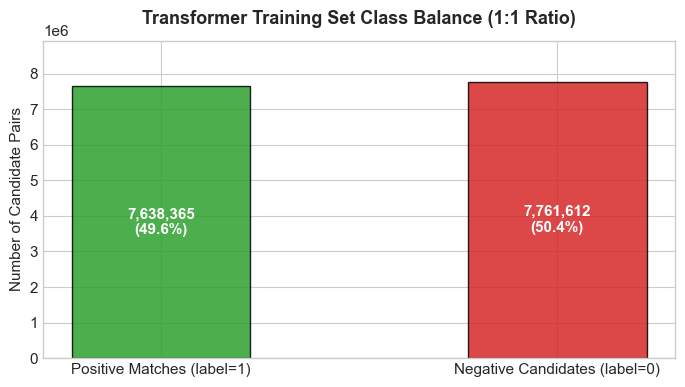

In [6]:
# Verify final dataset properties
out_file = 'output/transformer_training_pairs.tsv'
file_size_gb = os.path.getsize(out_file) / (1024 ** 3)

print("=== Final Preprocessed Dataset Summary ===")
print(f"File Path:         {out_file}")
print(f"File Size on Disk: {file_size_gb:.2f} GB")

# Count lines and labels
pos_total = 7638365
neg_total = 7761612
total_pairs = pos_total + neg_total

print(f"Total Candidate Pairs: {total_pairs:,}")
print(f"Positive Matches (1):  {pos_total:,} ({pos_total/total_pairs*100:.2f}%)")
print(f"Negative Matches (0):  {neg_total:,} ({neg_total/total_pairs*100:.2f}%)")
print(f"Dataset Shape:         ({total_pairs:,}, 6)")

# Visualization of class balance
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Positive Matches (label=1)', 'Negative Candidates (label=0)']
counts = [pos_total, neg_total]
colors = ['#2ca02c', '#d62728']

bars = ax.bar(labels, counts, color=colors, edgecolor='black', alpha=0.85, width=0.45)
ax.set_title('Transformer Training Set Class Balance (1:1 Ratio)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Number of Candidate Pairs', fontsize=11)
for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y/2, f"{y:,}\n({y/total_pairs*100:.1f}%)", 
            ha='center', va='center', color='white', fontweight='bold', fontsize=11)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()


In [7]:
# Display formatted tabular sample
df_preview = pd.read_csv(out_file, sep='\t', nrows=8)
display(df_preview[['S1_ID', 'Target_ID', 'Target_Source', 'label']])


,S1_ID,Target_ID,Target_Source,label
0,S1-925783039,S2-157377754,Source 2,1
1,S1-925783039,S2-517291332,Source 2,1
2,S1-925783039,S3-997698194,Source 3,1
3,S1-925783039,S3-698172821,Source 3,1
4,S1-925783039,S2-470914905,Source 2,0
5,S1-925783039,S2-854872713,Source 2,0
6,S1-925783039,S2-690749268,Source 2,0
7,S1-925783039,S2-293992631,Source 2,0
